In [4]:
# Ensure the project root is on PYTHONPATH when running from notebooks/
from pathlib import Path
import sys
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))



# 02 - OFO iteration (slow convergence to PID)

In [5]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

from hybrid_acdc.utils.io import load_json
from hybrid_acdc.cli.main import cmd_iterate
import argparse

cfg_path = '../config/system.yaml'
pid_ref_path = '../results/pid_ref/pid_ref.json'
out_dir = Path('../results/ofo'); out_dir.mkdir(parents=True, exist_ok=True)

args = argparse.Namespace(config=cfg_path, pid_ref=pid_ref_path, controller='ofo', out=str(out_dir),
                          iters=60, step_size=0.08, perturb=0.2, verbose=True)
cmd_iterate(args)

hist = load_json(out_dir/'iterate_history.json')
len(hist['history']), hist['history'][-1]


[ofo] iter 001/60: mean_cost=7802757044.8648  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.552  err_to_ref=0.9205
[ofo] iter 002/60: mean_cost=7802757026.6316  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.553  err_to_ref=0.9205
[ofo] iter 003/60: mean_cost=7719472902.7215  theta(vdc_kp)=30.000  theta(vdc_ki)=4993.6  alpha=0.552  err_to_ref=0.9206
[ofo] iter 004/60: mean_cost=7802757061.8278  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.550  err_to_ref=0.9205
[ofo] iter 005/60: mean_cost=7719472944.5485  theta(vdc_kp)=30.000  theta(vdc_ki)=4993.6  alpha=0.548  err_to_ref=0.9206
[ofo] iter 006/60: mean_cost=7663619829.9651  theta(vdc_kp)=30.000  theta(vdc_ki)=4987.2  alpha=0.550  err_to_ref=0.9207
[ofo] iter 007/60: mean_cost=7719472944.5485  theta(vdc_kp)=30.000  theta(vdc_ki)=4993.6  alpha=0.548  err_to_ref=0.9206
[ofo] iter 008/60: mean_cost=7802757061.8278  theta(vdc_kp)=30.000  theta(vdc_ki)=5000.0  alpha=0.550  err_to_ref=0.9205
[ofo] iter 009/60: mean_cost=771

(60,
 {'iter': 60,
  'mean_cost': 7802756904.299982,
  'theta': {'vdc_kp': 30.0, 'vdc_ki': 5000.0, 'alpha': 0.5435999999999999},
  'err_to_pid_ref': 0.920517855864105})

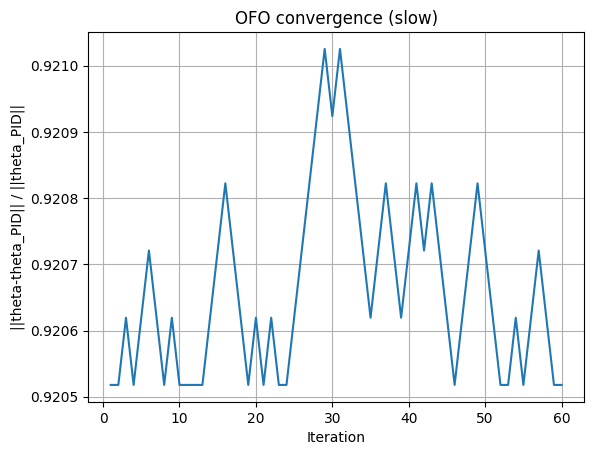

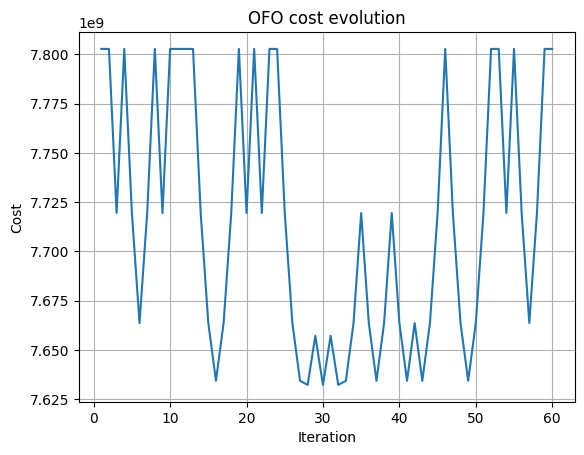

In [6]:
import numpy as np, matplotlib.pyplot as plt
h = hist['history']
its = [r['iter'] for r in h]
errs = [r['err_to_pid_ref'] for r in h]
J = [r['mean_cost'] for r in h]

plt.figure(); plt.plot(its, errs)
plt.xlabel('Iteration'); plt.ylabel('||theta-theta_PID|| / ||theta_PID||')
plt.grid(True); plt.title('OFO convergence (slow)')
plt.show()

plt.figure(); plt.plot(its, J)
plt.xlabel('Iteration'); plt.ylabel('Cost')
plt.grid(True); plt.title('OFO cost evolution')
plt.show()


In [6]:
from pathlib import Path
import sys

ROOT = Path('..').resolve()          # project root (same as before)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [7]:
from pathlib import Path
from hybrid_acdc.utils.io import load_json

out_dir_ofo = Path('../results/ofo')   # <-- OFO results folder
hist = load_json(out_dir_ofo / 'iterate_history.json')


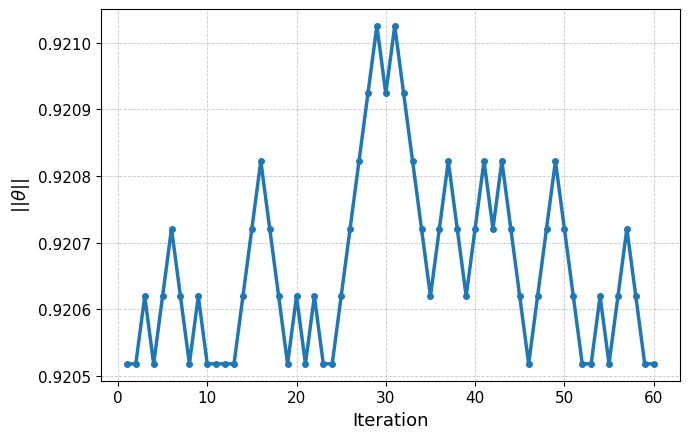

In [8]:
import matplotlib.pyplot as plt

h = hist['history']
its  = [r['iter'] for r in h]
errs = [r['err_to_pid_ref'] for r in h]

plt.figure(figsize=(7, 4.5))  # Same size as OFO-NN

plt.plot(
    its,
    errs,
    linewidth=2.5,
    marker='o',
    markersize=4
)

plt.xlabel('Iteration', fontsize=13)
plt.ylabel(r'$||\theta||$', fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.7)

plt.tight_layout()
plt.show()
